In [1]:
import time
import csv
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f"Đang sử dụng GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
else:
    print("Không tìm thấy GPU, sử dụng CPU")

Đang sử dụng GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
# ----- Cấu hình-----
latent_dim = 100
batch_size = 256 if torch.cuda.is_available() else 64
lr = 0.0003
epochs = 300

# For MNIST (grayscale)
nc = 1  # number of channels = 1 for MNIST
ngf = 64
ndf = 32

In [4]:
# ----- Dataset -----
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
train_loader = DataLoader(
    datasets.MNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True,
    pin_memory=True if device.type == 'cuda' else False
)

In [5]:
# ----- Weight init -----
def init_weights(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# ----- Generator (designed for 28x28 MNIST) -----
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        # We'll go: 1x1 -> 7x7 -> 14x14 -> 28x28
        self.model = nn.Sequential(
            # input: (N, latent_dim, 1, 1)
            nn.ConvTranspose2d(latent_dim, 64, kernel_size=7, stride=1, padding=0, bias=False),  # -> 7x7
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 4, kernel_size=4, stride=2, padding=1, bias=False),  # -> 14x14
            nn.BatchNorm2d(4),
            nn.ReLU(True),

            nn.ConvTranspose2d(4, nc, kernel_size=4, stride=2, padding=1, bias=False),   # -> 28x28
            nn.Tanh()  # output in [-1, 1]
        )

    def forward(self, z):
        # expect z shape (N, latent_dim) or (N, latent_dim, 1, 1)
        if z.dim() == 2:
            z = z.view(z.size(0), z.size(1), 1, 1)
        return self.model(z)

# ----- Discriminator (matching 28x28 input) -----
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # 28x28 -> 14x14 -> 7x7 -> 1x1
        self.model = nn.Sequential(
            nn.Conv2d(nc, ndf, kernel_size=4, stride=2, padding=1, bias=False),  # -> 14x14
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 10, kernel_size=4, stride=2, padding=1, bias=False),  # -> 7x7
            nn.BatchNorm2d(ndf * 10),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 10, 1, kernel_size=7, stride=1, padding=0, bias=False),  # -> 1x1
            nn.Sigmoid()
        )

    def forward(self, img):
        out = self.model(img)           # (N,1,1,1)
        return out.view(img.size(0), 1) # (N,1) to match your BCELoss targets

In [6]:
# ----- Khởi tạo mô hình và tối ưu hóa -----
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

generator.apply(init_weights)
discriminator.apply(init_weights)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

In [14]:
def model_params_size_bytes(model):
    params = sum(p.numel() * p.element_size() for p in model.parameters())
    buffers = sum(b.numel() * b.element_size() for b in model.buffers())
    return params + buffers

def n_paramters_approx(n_MB: float):
    n_Bytes = int(n_MB * (1024**2))
    n_parameters = n_Bytes // 4 #Cho rằng các tham số có kiểu dữ liệu float32
    
    return int(n_parameters)

def bytes_to_mb(b):
    return b / (1024**2)

generator_parameters_size = bytes_to_mb(model_params_size_bytes(generator))
discriminator_parameters_size = bytes_to_mb(model_params_size_bytes(discriminator))
total_size = generator_parameters_size + discriminator_parameters_size
print(f"Numbers of parameters: {n_paramters_approx(total_size):,}")

print(f"Model size (MB):\n\tGenerator: {generator_parameters_size:.2f} (MB)\n\tDiscriminator: {discriminator_parameters_size:.2f} (MB)\n\tTotal: {total_size:.2f} (MB)")


Numbers of parameters: 499,350
Model size (MB):
	Generator: 1.21 (MB)
	Discriminator: 0.69 (MB)
	Total: 1.90 (MB)


In [8]:
# Storage for metrics
history = {'epoch': 0, 'loss_D': [], 'loss_G': [], 'epoch_time_sec': []}

[Epoch 1/300] Loss_D: 0.0588, Loss_G: 3.5370, Time: 19.07s


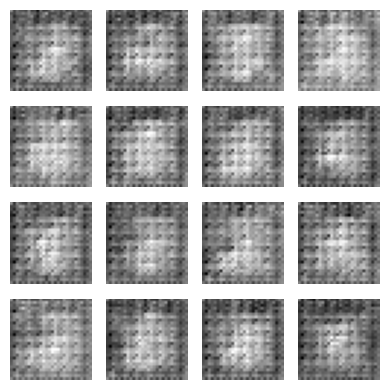

[Epoch 2/300] Loss_D: 0.0076, Loss_G: 4.6113, Time: 37.26s
[Epoch 3/300] Loss_D: 0.0011, Loss_G: 6.2894, Time: 57.18s
[Epoch 4/300] Loss_D: 0.0004, Loss_G: 7.3285, Time: 74.88s
[Epoch 5/300] Loss_D: 0.0002, Loss_G: 7.8092, Time: 92.68s
[Epoch 6/300] Loss_D: 0.0001, Loss_G: 8.3594, Time: 110.88s
[Epoch 7/300] Loss_D: 0.0001, Loss_G: 8.7892, Time: 129.10s
[Epoch 8/300] Loss_D: 0.0001, Loss_G: 9.0943, Time: 146.49s
[Epoch 9/300] Loss_D: 0.0001, Loss_G: 9.3239, Time: 163.96s
[Epoch 10/300] Loss_D: 0.0000, Loss_G: 9.6584, Time: 185.82s
[Epoch 11/300] Loss_D: 0.0000, Loss_G: 9.9325, Time: 210.11s
[Epoch 12/300] Loss_D: 0.0000, Loss_G: 10.1025, Time: 234.80s
[Epoch 13/300] Loss_D: 0.0000, Loss_G: 10.0566, Time: 259.34s
[Epoch 14/300] Loss_D: 0.0000, Loss_G: 10.2818, Time: 283.99s
[Epoch 15/300] Loss_D: 0.0000, Loss_G: 10.6004, Time: 305.55s
[Epoch 16/300] Loss_D: 0.0000, Loss_G: 10.8650, Time: 324.50s
[Epoch 17/300] Loss_D: 0.0000, Loss_G: 11.1006, Time: 342.52s
[Epoch 18/300] Loss_D: 0.0000,

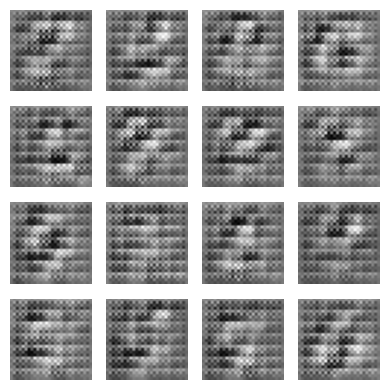

[Epoch 21/300] Loss_D: 0.0091, Loss_G: 6.6158, Time: 434.83s
[Epoch 22/300] Loss_D: 0.0079, Loss_G: 5.7043, Time: 456.72s
[Epoch 23/300] Loss_D: 0.0043, Loss_G: 5.9312, Time: 479.17s
[Epoch 24/300] Loss_D: 0.0030, Loss_G: 6.2434, Time: 498.12s
[Epoch 25/300] Loss_D: 0.0022, Loss_G: 6.5338, Time: 517.22s
[Epoch 26/300] Loss_D: 0.0015, Loss_G: 6.8935, Time: 538.36s
[Epoch 27/300] Loss_D: 0.0015, Loss_G: 6.8857, Time: 563.44s
[Epoch 28/300] Loss_D: 0.0016, Loss_G: 6.9162, Time: 586.80s
[Epoch 29/300] Loss_D: 0.1464, Loss_G: 6.8465, Time: 610.63s
[Epoch 30/300] Loss_D: 0.0829, Loss_G: 7.2305, Time: 634.07s
[Epoch 31/300] Loss_D: 0.0122, Loss_G: 6.2011, Time: 656.86s
[Epoch 32/300] Loss_D: 0.0158, Loss_G: 5.0058, Time: 677.04s
[Epoch 33/300] Loss_D: 0.0162, Loss_G: 4.7624, Time: 696.25s
[Epoch 34/300] Loss_D: 0.0129, Loss_G: 4.8770, Time: 716.34s
[Epoch 35/300] Loss_D: 0.0115, Loss_G: 5.0333, Time: 740.69s
[Epoch 36/300] Loss_D: 0.0130, Loss_G: 4.9902, Time: 764.54s
[Epoch 37/300] Loss_D: 0

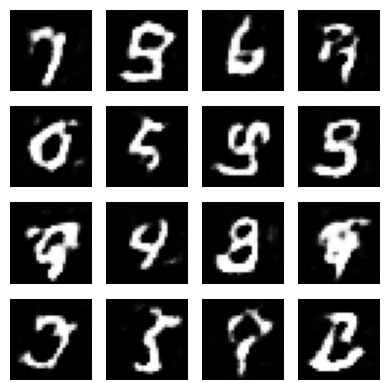

[Epoch 41/300] Loss_D: 0.0778, Loss_G: 3.9665, Time: 877.17s
[Epoch 42/300] Loss_D: 0.0542, Loss_G: 3.9394, Time: 897.99s
[Epoch 43/300] Loss_D: 0.0500, Loss_G: 3.9598, Time: 921.64s
[Epoch 44/300] Loss_D: 0.0481, Loss_G: 4.2160, Time: 963.61s
[Epoch 45/300] Loss_D: 0.0388, Loss_G: 4.4292, Time: 1007.32s
[Epoch 46/300] Loss_D: 0.0413, Loss_G: 4.5381, Time: 1050.50s
[Epoch 47/300] Loss_D: 0.0313, Loss_G: 4.5701, Time: 1099.10s
[Epoch 48/300] Loss_D: 0.0339, Loss_G: 4.7234, Time: 1144.41s
[Epoch 49/300] Loss_D: 0.0707, Loss_G: 4.7599, Time: 1164.20s
[Epoch 50/300] Loss_D: 0.0307, Loss_G: 4.7460, Time: 1184.80s
[Epoch 51/300] Loss_D: 0.0285, Loss_G: 4.6826, Time: 1206.70s
[Epoch 52/300] Loss_D: 0.0324, Loss_G: 4.7094, Time: 1224.54s
[Epoch 53/300] Loss_D: 0.0754, Loss_G: 4.8501, Time: 1246.31s
[Epoch 54/300] Loss_D: 0.0278, Loss_G: 4.8072, Time: 1268.06s
[Epoch 55/300] Loss_D: 0.0366, Loss_G: 4.9057, Time: 1289.02s
[Epoch 56/300] Loss_D: 0.1218, Loss_G: 4.7887, Time: 1311.61s
[Epoch 57/30

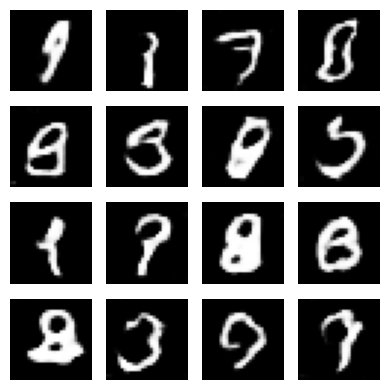

[Epoch 61/300] Loss_D: 0.0310, Loss_G: 4.6113, Time: 1424.77s
[Epoch 62/300] Loss_D: 0.0327, Loss_G: 4.7046, Time: 1447.39s
[Epoch 63/300] Loss_D: 0.0268, Loss_G: 4.8520, Time: 1471.03s
[Epoch 64/300] Loss_D: 0.0751, Loss_G: 5.0735, Time: 1494.68s
[Epoch 65/300] Loss_D: 0.0489, Loss_G: 5.1611, Time: 1519.65s
[Epoch 66/300] Loss_D: 0.0260, Loss_G: 5.1218, Time: 1542.42s
[Epoch 67/300] Loss_D: 0.0362, Loss_G: 5.0404, Time: 1566.80s
[Epoch 68/300] Loss_D: 0.0223, Loss_G: 5.2634, Time: 1586.86s
[Epoch 69/300] Loss_D: 0.0220, Loss_G: 5.3182, Time: 1607.18s
[Epoch 70/300] Loss_D: 0.0196, Loss_G: 5.3928, Time: 1629.72s
[Epoch 71/300] Loss_D: 0.0204, Loss_G: 5.5074, Time: 1654.06s
[Epoch 72/300] Loss_D: 0.1141, Loss_G: 5.1449, Time: 1681.81s
[Epoch 73/300] Loss_D: 0.0470, Loss_G: 4.8919, Time: 1708.78s
[Epoch 74/300] Loss_D: 0.0229, Loss_G: 5.0686, Time: 1736.06s
[Epoch 75/300] Loss_D: 0.0227, Loss_G: 5.3985, Time: 1762.68s
[Epoch 76/300] Loss_D: 0.0160, Loss_G: 5.5902, Time: 1790.77s
[Epoch 7

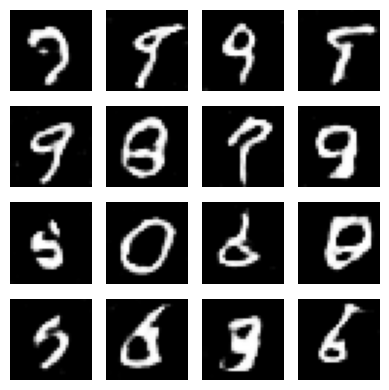

[Epoch 81/300] Loss_D: 0.0126, Loss_G: 5.8243, Time: 1926.39s
[Epoch 82/300] Loss_D: 0.0106, Loss_G: 5.9590, Time: 1956.08s
[Epoch 83/300] Loss_D: 0.0123, Loss_G: 5.9726, Time: 1979.18s
[Epoch 84/300] Loss_D: 0.0697, Loss_G: 5.7981, Time: 2000.68s
[Epoch 85/300] Loss_D: 0.0567, Loss_G: 5.7898, Time: 2021.63s
[Epoch 86/300] Loss_D: 0.0187, Loss_G: 5.4725, Time: 2042.63s
[Epoch 87/300] Loss_D: 0.0142, Loss_G: 5.7775, Time: 2066.06s
[Epoch 88/300] Loss_D: 0.0099, Loss_G: 6.0299, Time: 2088.53s
[Epoch 89/300] Loss_D: 0.0102, Loss_G: 6.1810, Time: 2110.74s
[Epoch 90/300] Loss_D: 0.0095, Loss_G: 6.2709, Time: 2132.42s
[Epoch 91/300] Loss_D: 0.3255, Loss_G: 6.3423, Time: 2154.47s
[Epoch 92/300] Loss_D: 0.0314, Loss_G: 7.3004, Time: 2176.92s
[Epoch 93/300] Loss_D: 0.0513, Loss_G: 4.4240, Time: 2198.91s
[Epoch 94/300] Loss_D: 0.0423, Loss_G: 4.6498, Time: 2220.78s
[Epoch 95/300] Loss_D: 0.0305, Loss_G: 4.8831, Time: 2242.57s
[Epoch 96/300] Loss_D: 0.0235, Loss_G: 5.1622, Time: 2264.68s
[Epoch 9

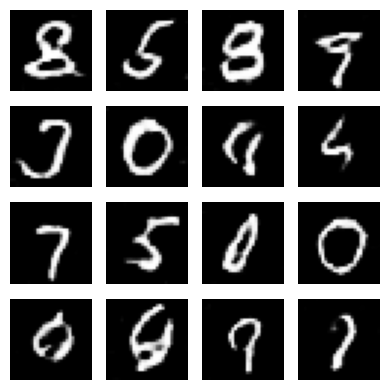

[Epoch 101/300] Loss_D: 0.0131, Loss_G: 6.1563, Time: 2376.24s
[Epoch 102/300] Loss_D: 0.0103, Loss_G: 6.3694, Time: 2398.02s
[Epoch 103/300] Loss_D: 0.0095, Loss_G: 6.4489, Time: 2420.15s
[Epoch 104/300] Loss_D: 0.0090, Loss_G: 6.5332, Time: 2441.36s
[Epoch 105/300] Loss_D: 0.2433, Loss_G: 5.3005, Time: 2462.41s
[Epoch 106/300] Loss_D: 0.1058, Loss_G: 4.7676, Time: 2480.93s
[Epoch 107/300] Loss_D: 0.0960, Loss_G: 4.2611, Time: 2502.75s
[Epoch 108/300] Loss_D: 0.0730, Loss_G: 4.5138, Time: 2524.06s
[Epoch 109/300] Loss_D: 0.0604, Loss_G: 4.5839, Time: 2544.89s
[Epoch 110/300] Loss_D: 0.0435, Loss_G: 4.6823, Time: 2566.27s
[Epoch 111/300] Loss_D: 0.0344, Loss_G: 4.8860, Time: 2588.37s
[Epoch 112/300] Loss_D: 0.0304, Loss_G: 5.1703, Time: 2610.11s
[Epoch 113/300] Loss_D: 0.0218, Loss_G: 5.3763, Time: 2631.52s
[Epoch 114/300] Loss_D: 0.0310, Loss_G: 5.6542, Time: 2652.66s
[Epoch 115/300] Loss_D: 0.0236, Loss_G: 5.7426, Time: 2674.43s
[Epoch 116/300] Loss_D: 0.0153, Loss_G: 5.8640, Time: 2

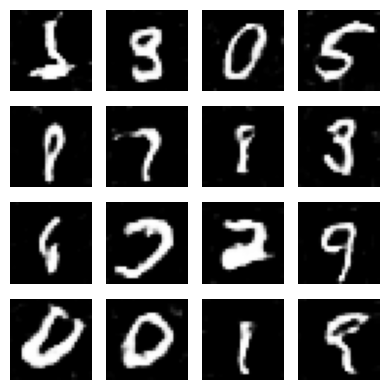

[Epoch 121/300] Loss_D: 0.0089, Loss_G: 6.3081, Time: 2803.57s
[Epoch 122/300] Loss_D: 0.0089, Loss_G: 6.4154, Time: 2824.64s
[Epoch 123/300] Loss_D: 0.0583, Loss_G: 6.1891, Time: 2847.11s
[Epoch 124/300] Loss_D: 0.0111, Loss_G: 6.2563, Time: 2869.50s
[Epoch 125/300] Loss_D: 0.0105, Loss_G: 6.3584, Time: 2890.96s
[Epoch 126/300] Loss_D: 0.0134, Loss_G: 6.4102, Time: 2912.46s
[Epoch 127/300] Loss_D: 0.0070, Loss_G: 6.6291, Time: 2935.16s
[Epoch 128/300] Loss_D: 0.0111, Loss_G: 6.6292, Time: 2956.55s
[Epoch 129/300] Loss_D: 0.0065, Loss_G: 6.8045, Time: 2978.69s
[Epoch 130/300] Loss_D: 0.0852, Loss_G: 6.8835, Time: 2999.88s
[Epoch 131/300] Loss_D: 0.0521, Loss_G: 6.5919, Time: 3021.23s
[Epoch 132/300] Loss_D: 0.0283, Loss_G: 5.7228, Time: 3043.46s
[Epoch 133/300] Loss_D: 0.0156, Loss_G: 5.9404, Time: 3065.03s
[Epoch 134/300] Loss_D: 0.0122, Loss_G: 6.2383, Time: 3086.35s
[Epoch 135/300] Loss_D: 0.0093, Loss_G: 6.3884, Time: 3108.60s
[Epoch 136/300] Loss_D: 0.0079, Loss_G: 6.5149, Time: 3

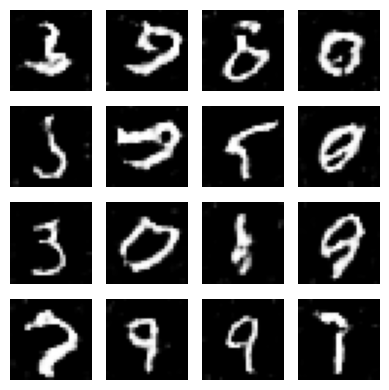

[Epoch 141/300] Loss_D: 0.0123, Loss_G: 6.6503, Time: 3238.89s
[Epoch 142/300] Loss_D: 0.0076, Loss_G: 6.6866, Time: 3260.40s
[Epoch 143/300] Loss_D: 0.0064, Loss_G: 6.7972, Time: 3281.36s
[Epoch 144/300] Loss_D: 0.0068, Loss_G: 6.9962, Time: 3302.55s
[Epoch 145/300] Loss_D: 0.0052, Loss_G: 7.1630, Time: 3326.40s
[Epoch 146/300] Loss_D: 0.0045, Loss_G: 7.2362, Time: 3348.92s
[Epoch 147/300] Loss_D: 0.0048, Loss_G: 7.2727, Time: 3373.37s
[Epoch 148/300] Loss_D: 0.0054, Loss_G: 7.3070, Time: 3396.15s
[Epoch 149/300] Loss_D: 0.1373, Loss_G: 7.3062, Time: 3416.18s
[Epoch 150/300] Loss_D: 0.0750, Loss_G: 6.9415, Time: 3437.31s
[Epoch 151/300] Loss_D: 0.0564, Loss_G: 5.2700, Time: 3458.13s
[Epoch 152/300] Loss_D: 0.0291, Loss_G: 5.3886, Time: 3476.75s
[Epoch 153/300] Loss_D: 0.0185, Loss_G: 5.6190, Time: 3499.10s
[Epoch 154/300] Loss_D: 0.0157, Loss_G: 5.9539, Time: 3521.72s
[Epoch 155/300] Loss_D: 0.0099, Loss_G: 6.3729, Time: 3544.61s
[Epoch 156/300] Loss_D: 0.0124, Loss_G: 6.5975, Time: 3

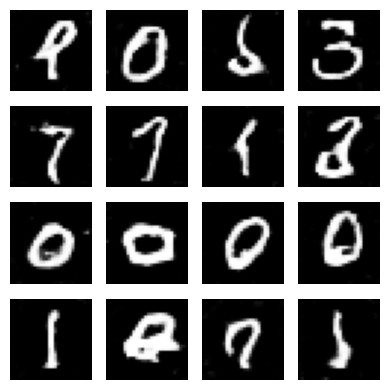

[Epoch 161/300] Loss_D: 0.0039, Loss_G: 7.4141, Time: 3674.85s
[Epoch 162/300] Loss_D: 0.0046, Loss_G: 7.4883, Time: 3695.92s
[Epoch 163/300] Loss_D: 0.0037, Loss_G: 7.6280, Time: 3716.18s
[Epoch 164/300] Loss_D: 0.3170, Loss_G: 7.2973, Time: 3737.98s
[Epoch 165/300] Loss_D: 0.0439, Loss_G: 5.5642, Time: 3760.20s
[Epoch 166/300] Loss_D: 0.0382, Loss_G: 5.4605, Time: 3782.59s
[Epoch 167/300] Loss_D: 0.0201, Loss_G: 5.7068, Time: 3805.26s
[Epoch 168/300] Loss_D: 0.0155, Loss_G: 5.9817, Time: 3826.72s
[Epoch 169/300] Loss_D: 0.0121, Loss_G: 6.2384, Time: 3847.43s
[Epoch 170/300] Loss_D: 0.0096, Loss_G: 6.5262, Time: 3868.14s
[Epoch 171/300] Loss_D: 0.0085, Loss_G: 6.6794, Time: 3889.44s
[Epoch 172/300] Loss_D: 0.0085, Loss_G: 6.7923, Time: 3910.63s
[Epoch 173/300] Loss_D: 0.0069, Loss_G: 6.9427, Time: 3933.05s
[Epoch 174/300] Loss_D: 0.0613, Loss_G: 7.0370, Time: 3954.33s
[Epoch 175/300] Loss_D: 0.0196, Loss_G: 6.4205, Time: 3974.13s
[Epoch 176/300] Loss_D: 0.0086, Loss_G: 6.7442, Time: 3

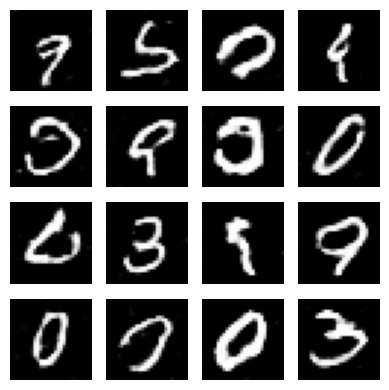

[Epoch 181/300] Loss_D: 0.0043, Loss_G: 7.5414, Time: 4098.78s
[Epoch 182/300] Loss_D: 0.0032, Loss_G: 7.6486, Time: 4119.84s
[Epoch 183/300] Loss_D: 0.0041, Loss_G: 7.6831, Time: 4141.79s
[Epoch 184/300] Loss_D: 0.0031, Loss_G: 7.8292, Time: 4161.71s
[Epoch 185/300] Loss_D: 0.1359, Loss_G: 7.5958, Time: 4183.21s
[Epoch 186/300] Loss_D: 0.0280, Loss_G: 5.9925, Time: 4204.79s
[Epoch 187/300] Loss_D: 0.0197, Loss_G: 5.9227, Time: 4224.25s
[Epoch 188/300] Loss_D: 0.0137, Loss_G: 6.2015, Time: 4242.53s
[Epoch 189/300] Loss_D: 0.0114, Loss_G: 6.4393, Time: 4260.48s
[Epoch 190/300] Loss_D: 0.0093, Loss_G: 6.6353, Time: 4278.27s
[Epoch 191/300] Loss_D: 0.0079, Loss_G: 6.8353, Time: 4296.43s
[Epoch 192/300] Loss_D: 0.0069, Loss_G: 7.0172, Time: 4328.29s
[Epoch 193/300] Loss_D: 0.0046, Loss_G: 7.3148, Time: 4384.21s
[Epoch 194/300] Loss_D: 0.0049, Loss_G: 7.4407, Time: 4435.49s
[Epoch 195/300] Loss_D: 0.0039, Loss_G: 7.5397, Time: 4495.94s
[Epoch 196/300] Loss_D: 0.0072, Loss_G: 7.5942, Time: 4

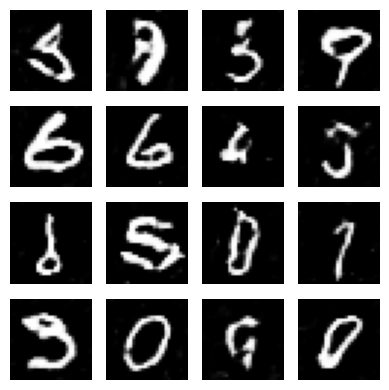

[Epoch 201/300] Loss_D: 0.0038, Loss_G: 7.5534, Time: 4837.25s
[Epoch 202/300] Loss_D: 0.0035, Loss_G: 7.6967, Time: 4889.11s
[Epoch 203/300] Loss_D: 0.0040, Loss_G: 7.7342, Time: 4940.29s
[Epoch 204/300] Loss_D: 0.0028, Loss_G: 7.9174, Time: 4996.61s
[Epoch 205/300] Loss_D: 0.0021, Loss_G: 8.1461, Time: 5047.88s
[Epoch 206/300] Loss_D: 0.0031, Loss_G: 8.1540, Time: 5099.61s
[Epoch 207/300] Loss_D: 0.0025, Loss_G: 8.2937, Time: 5155.74s
[Epoch 208/300] Loss_D: 0.0017, Loss_G: 8.5076, Time: 5207.24s
[Epoch 209/300] Loss_D: 0.2081, Loss_G: 7.4747, Time: 5268.32s
[Epoch 210/300] Loss_D: 0.0198, Loss_G: 6.0754, Time: 5320.89s
[Epoch 211/300] Loss_D: 0.0108, Loss_G: 6.4604, Time: 5372.13s
[Epoch 212/300] Loss_D: 0.0077, Loss_G: 6.7479, Time: 5425.48s
[Epoch 213/300] Loss_D: 0.0061, Loss_G: 7.0186, Time: 5476.58s
[Epoch 214/300] Loss_D: 0.0051, Loss_G: 7.2674, Time: 5527.69s
[Epoch 215/300] Loss_D: 0.0043, Loss_G: 7.4815, Time: 5579.43s
[Epoch 216/300] Loss_D: 0.0034, Loss_G: 7.7225, Time: 5

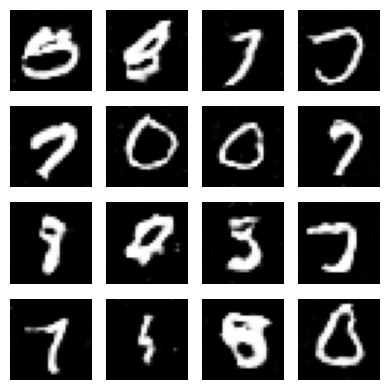

[Epoch 221/300] Loss_D: 0.0021, Loss_G: 8.2960, Time: 5887.16s
[Epoch 222/300] Loss_D: 0.0022, Loss_G: 8.3953, Time: 5938.40s
[Epoch 223/300] Loss_D: 0.0023, Loss_G: 8.4796, Time: 5990.03s
[Epoch 224/300] Loss_D: 0.0473, Loss_G: 8.6699, Time: 6038.06s
[Epoch 225/300] Loss_D: 0.0455, Loss_G: 6.8110, Time: 6089.15s
[Epoch 226/300] Loss_D: 0.0085, Loss_G: 7.0610, Time: 6144.67s
[Epoch 227/300] Loss_D: 0.0053, Loss_G: 7.3692, Time: 6192.67s
[Epoch 228/300] Loss_D: 0.0039, Loss_G: 7.5817, Time: 6237.95s
[Epoch 229/300] Loss_D: 0.0035, Loss_G: 7.7477, Time: 6282.43s
[Epoch 230/300] Loss_D: 0.0032, Loss_G: 7.8655, Time: 6326.92s
[Epoch 231/300] Loss_D: 0.0027, Loss_G: 8.0073, Time: 6368.85s
[Epoch 232/300] Loss_D: 0.0025, Loss_G: 8.1082, Time: 6409.63s
[Epoch 233/300] Loss_D: 0.0029, Loss_G: 8.1669, Time: 6452.84s
[Epoch 234/300] Loss_D: 0.0020, Loss_G: 8.3429, Time: 6494.56s
[Epoch 235/300] Loss_D: 0.1623, Loss_G: 7.5152, Time: 6536.75s
[Epoch 236/300] Loss_D: 0.0145, Loss_G: 6.7138, Time: 6

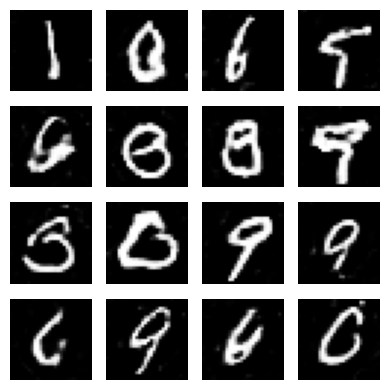

[Epoch 241/300] Loss_D: 0.0032, Loss_G: 7.8360, Time: 6795.17s
[Epoch 242/300] Loss_D: 0.0030, Loss_G: 7.9619, Time: 6837.17s
[Epoch 243/300] Loss_D: 0.0025, Loss_G: 8.1158, Time: 6877.45s
[Epoch 244/300] Loss_D: 0.0081, Loss_G: 8.0422, Time: 6919.91s
[Epoch 245/300] Loss_D: 0.0021, Loss_G: 8.3930, Time: 6960.54s
[Epoch 246/300] Loss_D: 0.0019, Loss_G: 8.5226, Time: 6999.82s
[Epoch 247/300] Loss_D: 0.0019, Loss_G: 8.6176, Time: 7041.29s
[Epoch 248/300] Loss_D: 0.0016, Loss_G: 8.7370, Time: 7082.71s
[Epoch 249/300] Loss_D: 0.0014, Loss_G: 8.8326, Time: 7123.55s
[Epoch 250/300] Loss_D: 0.2171, Loss_G: 7.8318, Time: 7164.07s
[Epoch 251/300] Loss_D: 0.0230, Loss_G: 6.2997, Time: 7200.08s
[Epoch 252/300] Loss_D: 0.0119, Loss_G: 6.3874, Time: 7263.19s
[Epoch 253/300] Loss_D: 0.0083, Loss_G: 6.7166, Time: 7316.90s
[Epoch 254/300] Loss_D: 0.0069, Loss_G: 6.9014, Time: 7368.26s
[Epoch 255/300] Loss_D: 0.0065, Loss_G: 7.1557, Time: 7419.93s
[Epoch 256/300] Loss_D: 0.0046, Loss_G: 7.3754, Time: 7

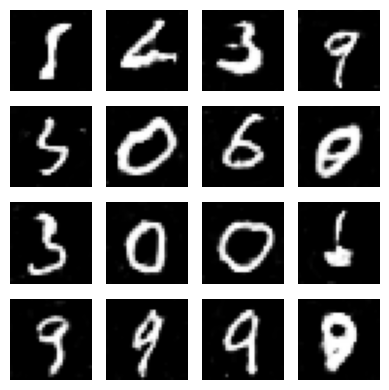

[Epoch 261/300] Loss_D: 0.0018, Loss_G: 8.4354, Time: 7728.36s
[Epoch 262/300] Loss_D: 0.0017, Loss_G: 8.5797, Time: 7778.90s
[Epoch 263/300] Loss_D: 0.0016, Loss_G: 8.6880, Time: 7827.61s
[Epoch 264/300] Loss_D: 0.0827, Loss_G: 8.2076, Time: 7876.63s
[Epoch 265/300] Loss_D: 0.0070, Loss_G: 7.3466, Time: 7925.51s
[Epoch 266/300] Loss_D: 0.0038, Loss_G: 7.7406, Time: 7973.98s
[Epoch 267/300] Loss_D: 0.0029, Loss_G: 8.0311, Time: 8022.65s
[Epoch 268/300] Loss_D: 0.0021, Loss_G: 8.2703, Time: 8071.05s
[Epoch 269/300] Loss_D: 0.0018, Loss_G: 8.4165, Time: 8119.03s
[Epoch 270/300] Loss_D: 0.0017, Loss_G: 8.5283, Time: 8167.24s
[Epoch 271/300] Loss_D: 0.0016, Loss_G: 8.6683, Time: 8214.74s
[Epoch 272/300] Loss_D: 0.0014, Loss_G: 8.7507, Time: 8263.38s
[Epoch 273/300] Loss_D: 0.0014, Loss_G: 8.8001, Time: 8310.53s
[Epoch 274/300] Loss_D: 0.0014, Loss_G: 8.8701, Time: 8359.31s
[Epoch 275/300] Loss_D: 0.2639, Loss_G: 8.1636, Time: 8407.71s
[Epoch 276/300] Loss_D: 0.0208, Loss_G: 6.3177, Time: 8

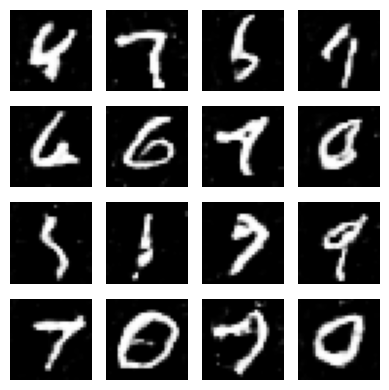

[Epoch 281/300] Loss_D: 0.0044, Loss_G: 7.5149, Time: 8691.22s
[Epoch 282/300] Loss_D: 0.0039, Loss_G: 7.6345, Time: 8731.04s
[Epoch 283/300] Loss_D: 0.0032, Loss_G: 7.8000, Time: 8749.36s
[Epoch 284/300] Loss_D: 0.0030, Loss_G: 7.9318, Time: 8766.45s
[Epoch 285/300] Loss_D: 0.0029, Loss_G: 8.0227, Time: 8785.86s
[Epoch 286/300] Loss_D: 0.0148, Loss_G: 7.9819, Time: 8806.19s
[Epoch 287/300] Loss_D: 0.0030, Loss_G: 8.1671, Time: 8827.17s
[Epoch 288/300] Loss_D: 0.0021, Loss_G: 8.4138, Time: 8846.89s
[Epoch 289/300] Loss_D: 0.0017, Loss_G: 8.5266, Time: 8867.77s
[Epoch 290/300] Loss_D: 0.0019, Loss_G: 8.5462, Time: 8889.25s
[Epoch 291/300] Loss_D: 0.0014, Loss_G: 8.6489, Time: 8909.05s
[Epoch 292/300] Loss_D: 0.0019, Loss_G: 8.7609, Time: 8927.89s
[Epoch 293/300] Loss_D: 0.0015, Loss_G: 8.8566, Time: 8945.60s
[Epoch 294/300] Loss_D: 0.0014, Loss_G: 8.9625, Time: 8964.89s
[Epoch 295/300] Loss_D: 0.0010, Loss_G: 9.1283, Time: 8986.70s
[Epoch 296/300] Loss_D: 0.0027, Loss_G: 9.0548, Time: 9

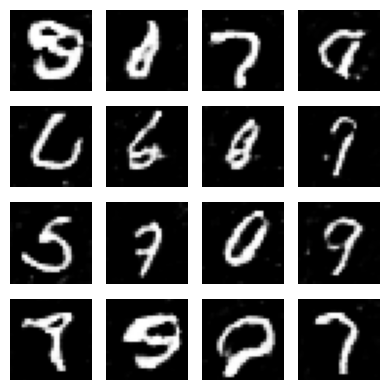

In [9]:
# ----- Training loop-----
t0 = time.perf_counter()
for epoch in range(1, epochs + 1):
    epoch_loss_D = 0.0
    epoch_loss_G = 0.0

    for real_imgs, _ in train_loader:
        real_imgs = real_imgs.to(device, non_blocking=True)
        b = real_imgs.size(0)

        valid = torch.ones(b, 1, device=device)
        fake = torch.zeros(b, 1, device=device)

        # -- Discriminator
        optimizer_D.zero_grad()
        loss_real = criterion(discriminator(real_imgs), valid)

        z = torch.randn(b, latent_dim, device=device)
        gen_imgs = generator(z)  # generator returns (b,1,28,28)
        loss_fake = criterion(discriminator(gen_imgs.detach()), fake)

        loss_D = 0.5 * (loss_real + loss_fake)
        loss_D.backward()
        optimizer_D.step()

        # -- Generator
        optimizer_G.zero_grad()
        loss_G = criterion(discriminator(gen_imgs), valid)
        loss_G.backward()
        optimizer_G.step()

        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()

    avg_loss_D = epoch_loss_D / len(train_loader)
    avg_loss_G = epoch_loss_G / len(train_loader)
    elapsed = time.perf_counter() - t0

    history['epoch'] += 1
    history['loss_D'].append(avg_loss_D)
    history['loss_G'].append(avg_loss_G)
    history['epoch_time_sec'].append(elapsed)

    print(f"[Epoch {epoch}/{epochs}] Loss_D: {avg_loss_D:.4f}, Loss_G: {avg_loss_G:.4f}, Time: {elapsed:.2f}s")

    if epoch % 20 == 0 or epoch == 1:
        with torch.no_grad():
            test_z = torch.randn(16, latent_dim, device=device)
            test_imgs = generator(test_z).cpu()
            fig, axes = plt.subplots(4, 4, figsize=(4, 4))
            for img, ax in zip(test_imgs, axes.flatten()):
                ax.imshow(img.squeeze() * 0.5 + 0.5, cmap='gray')
                ax.axis('off')
            plt.tight_layout()
            plt.show()

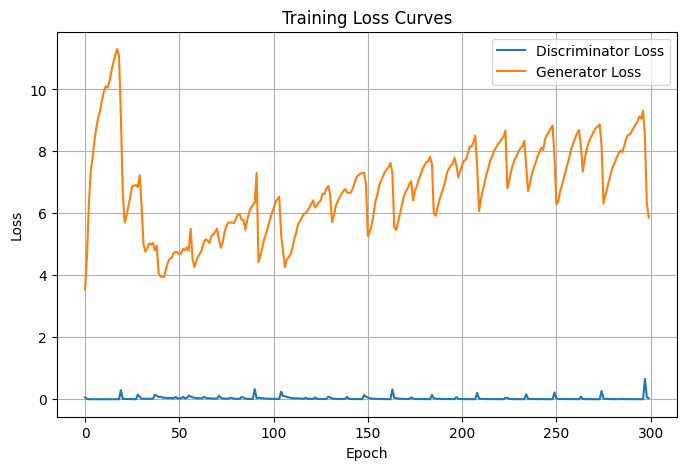

In [10]:
# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(300), history['loss_D'], label='Discriminator Loss')
plt.plot(range(300), history['loss_G'], label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss Curves')
plt.grid(True)
plt.show()

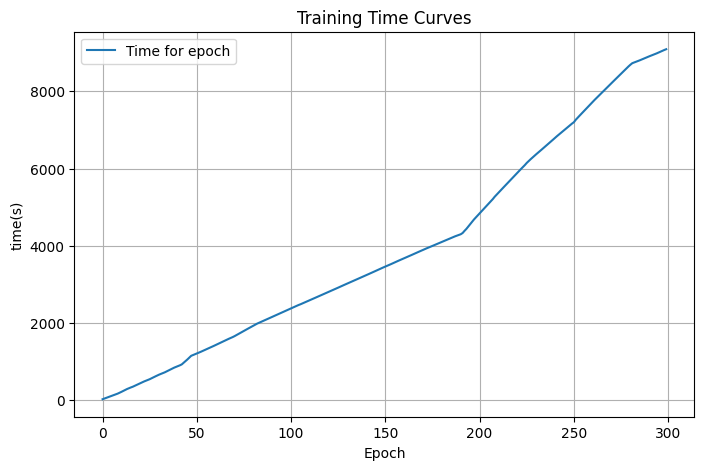

In [11]:
# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(300), history['epoch_time_sec'], label='Time for epoch')
plt.xlabel('Epoch')
plt.ylabel('time(s)')
plt.legend()
plt.title('Training Time Curves')
plt.grid(True)
plt.show()

In [12]:
# Export to CSV
csv_file = 'DCGAN_training_history.csv'
with open(csv_file, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['epoch', 'loss_D', 'loss_G', 'epoch_time_sec'])
    writer.writeheader()
    for e, ld, lg, t in zip(range(history['epoch']), history['loss_D'], history['loss_G'], history['epoch_time_sec']):
        writer.writerow({'epoch': e, 'loss_D': ld, 'loss_G': lg, 'epoch_time_sec': t})

print(f"Training history exported to {csv_file}")

Training history exported to DCGAN_training_history.csv


In [13]:
# import os
# def read_history_from_file(path, history):
#     """
#     Read training history from a CSV or JSON file and merge into `history` dict.
#     - `path`: path to CSV or JSON file (supports .csv and .json).
#     - `history`: dict expected to contain at least 'epoch' and some list fields, e.g.
#         {'epoch': 0, 'loss_D': [], 'loss_G': [], 'epoch_time_sec': []}
#     Returns updated history (same object).
#     """
#     if not os.path.isfile(path):
#         raise FileNotFoundError(f"No file at: {path}")

#     ext = os.path.splitext(path)[1].lower()
#     rows = []

#     if ext == '.csv':
#         with open(path, 'r', newline='') as f:
#             reader = csv.DictReader(f)
#             for r in reader:
#                 rows.append(r)
#     elif ext == '.json':
#         with open(path, 'r') as f:
#             data = json.load(f)
#             # Accept either list-of-rows or dict-of-lists
#             if isinstance(data, list):
#                 rows = data
#             elif isinstance(data, dict):
#                 # convert dict-of-lists to list-of-rows
#                 keys = list(data.keys())
#                 # find length
#                 length = len(data[keys[0]]) if keys else 0
#                 for i in range(length):
#                     row = {k: data[k][i] for k in keys}
#                     rows.append(row)
#             else:
#                 raise ValueError("JSON format not recognized: must be list or dict-of-lists")
#     else:
#         raise ValueError("Unsupported file extension. Use .csv or .json")

#     # Parse rows into canonical numeric values
#     parsed = []
#     for r in rows:
#         parsed_row = {}
#         for k, v in r.items():
#             if v is None or v == '':
#                 parsed_row[k] = None
#                 continue
#             # try int then float else keep string
#             try:
#                 iv = int(v)
#                 parsed_row[k] = iv
#             except Exception:
#                 try:
#                     fv = float(v)
#                     parsed_row[k] = fv
#                 except Exception:
#                     parsed_row[k] = v
#         parsed.append(parsed_row)

#     # Which epochs already in history?
#     existing_epochs = set()
#     if 'epoch' in history and isinstance(history['epoch'], int):
#         # history['epoch'] stores last epoch count, but we need epoch numbers present in lists
#         # Try to reconstruct existing epoch list length from one of the loss lists (if present).
#         # We'll treat history lists as aligned in order.
#         existing_len = None
#         for key, val in history.items():
#             if key == 'epoch': 
#                 continue
#             if isinstance(val, list):
#                 if existing_len is None or len(val) > existing_len:
#                     existing_len = len(val)
#         if existing_len is not None:
#             # assume stored epochs are 1..existing_len
#             existing_epochs = set(range(1, existing_len + 1))
#         else:
#             existing_epochs = set()

#     # Merge: determine numeric epoch column name (may be 'epoch' or 'Epoch')
#     epoch_key = None
#     if parsed:
#         possible_epoch_names = ['epoch', 'Epoch', 'iter', 'iteration', 'step']
#         for name in possible_epoch_names:
#             if name in parsed[0]:
#                 epoch_key = name
#                 break
#         # fallback to first numeric column if no 'epoch' found
#         if epoch_key is None:
#             # choose the first key whose values are ints across rows
#             for k in parsed[0].keys():
#                 if all(isinstance(row.get(k, None), int) for row in parsed):
#                     epoch_key = k
#                     break

#     if epoch_key is None:
#         raise ValueError("Couldn't find an epoch/step column in the file. Expected column named 'epoch' or similar.")

#     # Ensure history has list containers for all columns found (except epoch)
#     for k in parsed[0].keys():
#         if k == epoch_key:
#             continue
#         if k not in history:
#             history[k] = []

#     # Append only new epochs (avoid duplicates)
#     appended = 0
#     for row in parsed:
#         ep = row.get(epoch_key)
#         if ep is None:
#             continue
#         if ep in existing_epochs:
#             continue
#         # append values for each key in history (skip epoch key)
#         for k in history.keys():
#             if k == 'epoch':
#                 continue
#             history[k].append(row.get(k))
#         appended += 1
#         existing_epochs.add(ep)

#     # Update history['epoch'] to max epoch (if numeric rows exist)
#     epochs_in_file = [r.get(epoch_key) for r in parsed if isinstance(r.get(epoch_key), (int, float))]
#     if epochs_in_file:
#         # take max int
#         max_epoch = int(max(epochs_in_file))
#         if 'epoch' in history and isinstance(history['epoch'], int):
#             history['epoch'] = max(history['epoch'], max_epoch)
#         else:
#             history['epoch'] = max_epoch

#     print(f"Read {len(parsed)} rows from '{path}', appended {appended} new entries to history.")
#     return history